In [3]:
import os
from qiskit_ibm_runtime import QiskitRuntimeService

token = os.getenv("IBM_QUANTUM_TOKEN")
print(f"Token loaded: {'Yes' if token else 'No'}")

if token:
    QiskitRuntimeService.save_account(
        channel="ibm_quantum",
        token=token,
        overwrite=True  # This will overwrite the existing account
    )
    print("Account updated successfully!")

Token loaded: Yes
Account updated successfully!


In [4]:
# Qiskit tools
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import circuit_drawer
from qiskit_aer.noise import NoiseModel

# Python packages
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# NEW Qiskit 2.0.2 equivalent:
from qiskit_ibm_runtime import QiskitRuntimeService

# Set devices, if using a real device
service = QiskitRuntimeService(channel="ibm_quantum")  # or "ibm_quantum" if not migrated yet

# Get backend - note the name change: 'ibmq_quito' -> 'ibm_quito'
try:
    quito = service.backend('ibm_quito')
    print(f"Connected to: {quito.name}")
except Exception as e:
    print(f"Quito not available: {e}")
    # Alternative: use available backends
    print("Available backends:")
    for backend in service.backends(simulator=False, operational=True):
        print(f"- {backend.name}")
    
    # Use Brisbane or Sherbrooke as alternatives (more powerful anyway)
    quito = service.backend('ibm_brisbane')  # 127 qubits vs quito's 5
    print(f"Using {quito.name} instead ({quito.configuration().n_qubits} qubits)")

/var/folders/bb/nb0_h50d2gl5mky8649bmq0r0000gn/T/ipykernel_39069/1356069310.py:5: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService(channel="ibm_quantum")  # or "ibm_quantum" if not migrated yet


Quito not available: 'No backend matches the criteria.'
Available backends:
- ibm_brisbane
- ibm_sherbrooke
Using ibm_brisbane instead (127 qubits)


In [6]:
sim = Aer.get_backend('aer_simulator')

In [7]:
def make_chsh_circuit(theta_vec):
    """Return a list of QuantumCircuits for use in a CHSH experiemnt
    (one for each value of theta in theta_vec)
    
        Args:
            theta_vec (list): list of values of angles between the bases of Alice and Bob
        
        Returns:
            List[QuantumCircuit]: CHSH QuantumCircuits for each value of theta
    """
    chsh_circuits = []
    
    for theta in theta_vec:
        obs_vec = ['00', '01', '10', '11']
        for el in obs_vec:
            qc = QuantumCircuit(2,2)
            qc.h(0)
            qc.cx(0, 1)
            qc.ry(theta, 0)
            for a in range(2):
                if el[a] == '1':
                    qc.h(a) 
            qc.measure(range(2),range(2))
            chsh_circuits.append(qc)

    return chsh_circuits  


In [8]:
def compute_chsh_witness(counts):
    """Computes expectation values for the CHSH inequality, for each
    angle (theta) between measurement axis.

        Args: counts (list[dict]): dict of counts for each experiment
              (4 per value of theta)

        Returns:
            Tuple(List, List): Tuple of lists with the two CHSH witnesses
    """
    # Order is ZZ,ZX,XZ,XX
    
    CHSH1 = []
    CHSH2 = []
    # Divide the list of dictionaries in sets of 4
    for i in range(0, len(counts), 4):  
        theta_dict = counts[i:i + 4]
        zz = theta_dict[0]
        zx = theta_dict[1]
        xz = theta_dict[2]
        xx = theta_dict[3]

        no_shots = sum(xx[y] for y in xx)

        chsh1 = 0
        chsh2 = 0

        for element in zz:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1+= parity*zz[element]
            chsh2+= parity*zz[element]

        for element in zx:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1+= parity*zx[element]
            chsh2-= parity*zx[element]

        for element in xz:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1-= parity*xz[element]
            chsh2+= parity*xz[element]

        for element in xx:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1+= parity*xx[element]
            chsh2+= parity*xx[element]

        CHSH1.append(chsh1/no_shots)
        CHSH2.append(chsh2/no_shots)
    
    return CHSH1, CHSH2

In [9]:
number_of_thetas = 15
theta_vec = np.linspace(0,2*np.pi,number_of_thetas)
my_chsh_circuits = make_chsh_circuit(theta_vec)

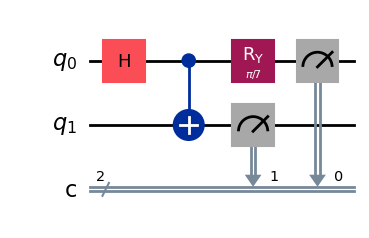

In [10]:
my_chsh_circuits[4].draw('mpl')

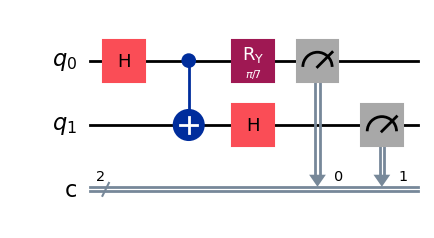

In [11]:
my_chsh_circuits[5].draw('mpl')

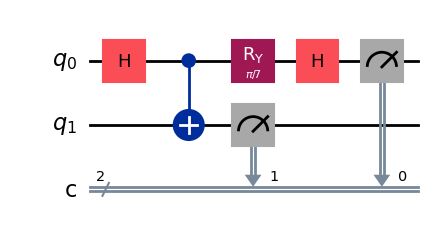

In [12]:
my_chsh_circuits[6].draw('mpl')

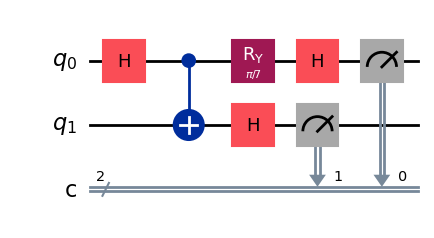

In [13]:
my_chsh_circuits[7].draw('mpl')

In [14]:
# Required imports for Qiskit 2.0.2 Primitives
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Sampler  # Use Sampler instead of SamplerV2
import time

# Initialize simulator
sim = AerSimulator()

# Execute on simulator (old way still works for AerSimulator)
result_ideal = sim.run(my_chsh_circuits, shots=8192).result()
print("✓ Simulator execution completed")

# Execute on real hardware using Primitives (NEW way for IBM backends)
tic = time.time()
try:
    # Transpile circuits for the target backend
    transpiled_circuits = transpile(my_chsh_circuits, quito)
    print(f"Transpiled {len(transpiled_circuits)} circuits for {quito.name}")
    
    # Use Sampler primitive instead of backend.run()
    sampler = Sampler(backend=quito)
    
    # Submit job using the primitive
    job_real = sampler.run(transpiled_circuits, shots=8192)
    print(f"Job submitted: {job_real.job_id()}")
    print("Waiting for job to complete...")
    
    # Get results (this blocks until completion)
    result_real = job_real.result()
    toc = time.time()
    
    print(f"✓ Hardware execution completed in {toc-tic:.2f} seconds")
    print(f"✓ Job status: {job_real.status()}")
    
except Exception as e:
    toc = time.time()
    print(f"✗ Job execution failed after {toc-tic:.2f} seconds")
    print(f"Error: {e}")

print(f"Total execution time: {toc-tic:.2f} seconds")

# Note: Results structure is different with primitives
# result_real[0].data will contain your measurement results
# You may need to adapt how you access the counts

✓ Simulator execution completed
Transpiled 60 circuits for ibm_brisbane
✗ Job execution failed after 2.84 seconds
Error: SamplerV2.__init__() got an unexpected keyword argument 'backend'
Total execution time: 2.84 seconds


In [19]:
# Simple test to verify your connection works
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import Sampler

# Create minimal test circuit
test_qc = QuantumCircuit(2, 2)
test_qc.h(0)
test_qc.measure_all()

try:
    backend = service.backend('ibm_brisbane')  # or another available backend
    sampler = Sampler(backend)
    job = sampler.run([test_qc], shots=100)  # Small test
    result = job.result()
    print("✅ Real hardware connection works!")
    print(f"Test result: {result.get_counts()}")
except Exception as e:
    print(f"❌ Connection test failed: {e}")

❌ Connection test failed: 'The instruction h on qubits (0,) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'


NameError: name 'CHSH1_real' is not defined

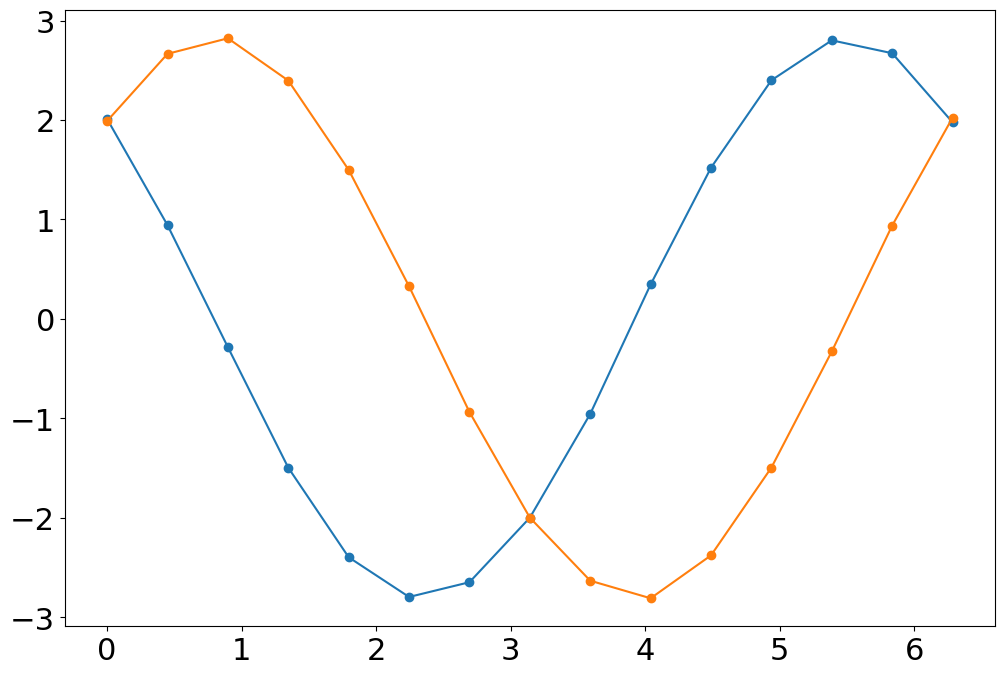

In [54]:
plt.figure(figsize=(12,8))
plt.rcParams.update({'font.size': 22})
plt.plot(theta_vec,CHSH1_ideal,'o-',label = 'CHSH1 Noiseless')
plt.plot(theta_vec,CHSH2_ideal,'o-',label = 'CHSH2 Noiseless')

plt.plot(theta_vec,CHSH1_real,'x-',label = 'CHSH1 Quito')
plt.plot(theta_vec,CHSH2_real,'x-',label = 'CHSH2 Quito')

plt.grid(which='major',axis='both')
plt.rcParams.update({'font.size': 16})
plt.legend()
plt.axhline(y=2, color='r', linestyle='-')
plt.axhline(y=-2, color='r', linestyle='-')
plt.axhline(y=np.sqrt(2)*2, color='k', linestyle='-.')
plt.axhline(y=-np.sqrt(2)*2, color='k', linestyle='-.')
plt.xlabel('Theta')
plt.ylabel('CHSH witness')